<a href="https://colab.research.google.com/github/forSplinter/free_llm_2026_Intership/blob/dev/TOPIC_MODELING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

#replace with the project folder e.g 'free/LLM_free_2O26/xxxxx'
FOLDERNAME = 'free_LLM_2026/technical_test'
assert FOLDERNAME is not None
PROJECT_DIR = f"/content/drive/MyDrive/{FOLDERNAME}"

import sys
sys.path.append(PROJECT_DIR)
%cd $PROJECT_DIR

Mounted at /content/drive
/content/drive/MyDrive/free_LLM_2026/technical_test


La suite de notre exploration se concentrera sur le topic modeling. L’objectif est de construire un modèle capable, à partir d’un verbatim utilisateur, de classifier l’intention (Detractor, Passif, Promotor), mais également d’identifier le problème ou le besoin réellement exprimé. Cette double lecture permettra d’améliorer l’offre, de mieux comprendre les irritants clients et de proposer des pistes concrètes d’optimisation.

Pour répondre à cet objectif, nous retenons NMF pour ça lecture simple mais aussi a cause de la longueur de nos verbatim qui sont assez court, utiliser un model comme BERTopic ne nous aiderais pas a mieux comprendre les sous thèmes

In [19]:
import os
import numpy as np
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
SEED = 42

ls = os.path.abspath('data')
df = pd.read_csv(ls + '/csat_final_clean.csv')
df.head()

,csat,nps,commentaire,nps_segment,clean_commentaire,tokens
0,3,6,on donne toutes les infos à l’engagement et im...,Detractor,donne toutes infos a l'engagement immediatemen...,"['donne', 'toutes', 'infos', 'a', ""l'engagemen..."
1,4,7,"Saisi du Rio pas claire. Minuscule, pas Minusc...",Passif,saisi rio claire minuscule minuscule espace es...,"['saisi', 'rio', 'claire', 'minuscule', 'minus..."
2,5,8,Il manque la possibilité de choisir une date d...,Passif,manque possibilite choisir date portabilite en...,"['manque', 'possibilite', 'choisir', 'date', '..."
3,5,9,MERCI,Promoter,merci,['merci']
4,4,8,Il manque peut-être des précisions sur la pris...,Passif,manque peut etre precisions prise charge resil...,"['manque', 'peut', 'etre', 'precisions', 'pris..."


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38302 entries, 0 to 38301
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   csat               38302 non-null  int64 
 1   nps                38302 non-null  int64 
 2   commentaire        38302 non-null  object
 3   nps_segment        38302 non-null  object
 4   clean_commentaire  38120 non-null  object
 5   tokens             38302 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.8+ MB


In [21]:
import nltk
import spacy
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_fr = list(stopwords.words("french"))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Nous avons déjas fais l'exploration du texte dans la partie présédente ici nous allons droit au but, avec une version automatisé de NMF pour ça on vas utiliser le framework gensim

In [8]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.5 MB/s eta 0:00:00


In [27]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from gensim.models.nmf import Nmf
from collections import Counter
from operator import itemgetter
import ast

In [29]:
texts = df['clean_commentaire'].astype(str).str.split()
#for mapping words between their id useful for gensim
dictionary = Dictionary(texts)
#And we filter for limit the number of features
dictionary.filter_extremes(
    no_below=5,
    no_above=0.75,
    keep_n=8000
)

In [46]:
corpus = [dictionary.doc2bow(text) for text in texts]
topic_nums = list(np.arange(10, 40 + 1, 10))#if we want more granuality we can add another lis just do +list(np.arange(_,_,_))
#After a first exploration i reduce the topic num and theak the nmf

In [47]:
coherence_scores = []
for num in topic_nums:
  nmf = Nmf(corpus=corpus,
            num_topics=num,
            id2word=dictionary,
            chunksize=4000,
            passes=15,
            kappa=.1,
            minimum_probability=0.001,
            w_max_iter=400,
            w_stop_condition=1e-5,
            h_max_iter=150,
            h_stop_condition=1e-4,
            eval_every=5,
            normalize=True,
            random_state=SEED
            )
  cm = CoherenceModel(
      model=nmf,
      texts=texts,
      dictionary=dictionary,
      coherence='c_v'
    )
  coherence_scores.append(round(cm.get_coherence(), 5))

In [48]:
#Get the number of topic with the highest score, sorted them
scores = list(zip(topic_nums, coherence_scores))
best_num_topics = sorted(scores, key=itemgetter(1), reverse=True)[0][0]


(array([0.64 , 0.645, 0.65 , 0.655, 0.66 , 0.665, 0.67 , 0.675, 0.68 ]),
 [Text(0, 0.64, '0.640'),
  Text(0, 0.645, '0.645'),
  Text(0, 0.65, '0.650'),
  Text(0, 0.655, '0.655'),
  Text(0, 0.66, '0.660'),
  Text(0, 0.665, '0.665'),
  Text(0, 0.67, '0.670'),
  Text(0, 0.675, '0.675'),
  Text(0, 0.68, '0.680')])

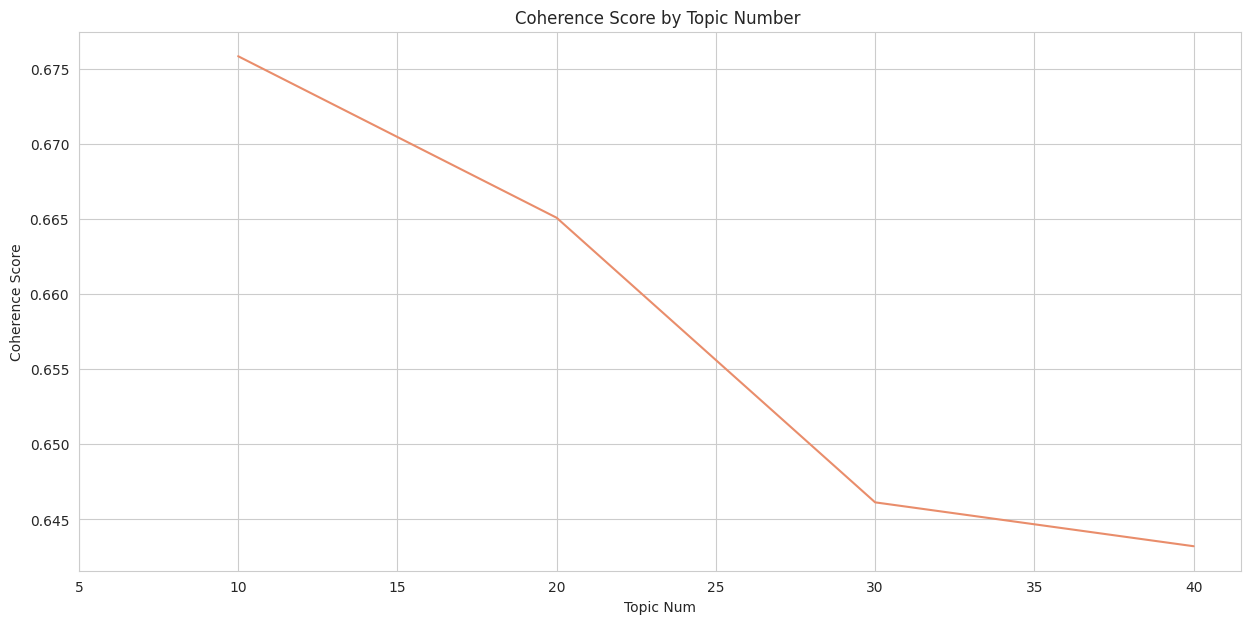

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set_palette('flare')
sns.set_style(style='whitegrid')
plt.figure(figsize=(15, 7))
plt.plot(topic_nums, coherence_scores)
plt.xlabel("Topic Num")
plt.ylabel("Coherence Score")
plt.title('Coherence Score by Topic Number ')
plt.xticks(np.arange(5, max(topic_nums) + 1, 5))
plt.yticks()

Pour le nombre de topic nous partons dans un premier temps sur une range entre 10 et 100 pour tester la granularité des topics puis passons au final entre 5 et 40 qui semble etres un bon compris sans prendre trop de temps à compute le score 10 reste celui avec le plus haut score (+0.67) tout en décendant graduelement et de manière assez douce une bonne range donc.

Pour voir choisir le meilleur nombre de topic il faut directement tester sur notre dataset et voir la cohérence sans ça on ne pas affirmé que 10 soit la meilleur solution malgré son score élevé.

après un lookup et quelque teste je vais rester sur 20 topic. Comment il suffit de changer le NMF nums_topic et de regarder les topic

## Summurazi or topic

on vas le faire automatiquement aucun humain n'a envie d'aller dan chaque texte et de le faire manuellement pour ça on peut se remettre a TF-IDF, utilisant les mots de chaque topic qui ont obtenu le score le plus élevé pour ce topic, puis à les associer aux noms des fonctionnalités. on part sur le top_10 pour voir

In [56]:
tfidf_vectorizer = TfidfVectorizer(
    min_df=4,
    max_df=0.82,
    max_features=6000,
    ngram_range=(1, 2),
    preprocessor=' '.join
)
tfidf = tfidf_vectorizer.fit_transform(texts)
tfidf_fn = tfidf_vectorizer.get_feature_names_out()

In [67]:
#We re run nmf on the best topic score now with some new adjustment
nmf = NMF(n_components=20,
          init='nndsvd',
          max_iter=800,
          l1_ratio=0.0,
          solver='cd',
          alpha_W=0.0,
          alpha_H=0.0,
          tol=1e-4,
          beta_loss='frobenius',
          random_state=SEED
        ).fit(tfidf)

In [74]:
from typing import List, Any

def top_words(topic:np.array_str, n_top_words:int)->np.array:
    return topic.argsort()[:-n_top_words - 1:-1]

def topic_table(model: Any, feature_names: List[str], n_top_words: int) -> pd.DataFrame:
    topics = {}
    for idx, topic in enumerate(model.components_):
        t = (idx)
        topics[t] = [feature_names[i] for i in top_words(topic, n_top_words)]
    return pd.DataFrame(topics)


In [96]:
n_top_words = 10
docweights = nmf.transform(tfidf_vectorizer.transform(texts))
topic_df = topic_table(
    nmf,
    tfidf_fn,
    n_top_words
).T

In [97]:
from nltk.tokenize import TweetTokenizer, RegexpTokenizer
def whitespace_tokenizer(text:List[str]):
    pattern = r"(?u)\b\w\w+\b"
    tokenizer_regex = RegexpTokenizer(pattern)
    tokens = tokenizer_regex.tokenize(text)
    return tokens

In [98]:
#After a quick view it seem i need to deal with duplicate words
def unique_words(text):
    ulist = []
    [ulist.append(x) for x in text if x not in ulist]
    return ulist

In [99]:
topic_df['topics'] = topic_df.apply(lambda x: [' '.join(x)], axis=1) # Joining each word into a list
topic_df['topics'] = topic_df['topics'].str[0]  # Removing the list brackets
topic_df['topics'] = topic_df['topics'].apply(lambda x: whitespace_tokenizer(x)) # tokenize
topic_df['topics'] = topic_df['topics'].apply(lambda x: unique_words(x))  # Removing duplicate words
topic_df['topics'] = topic_df['topics'].apply(lambda x: [' '.join(x)])  # Joining each word into a list
topic_df['topics'] = topic_df['topics'].str[0]  # Removing the list brackets

topic_df.head()

,0,1,2,3,4,5,6,7,8,9,topics
0,merci,parfait merci,grand merci,grand,reactivite,bien merci,top merci,merci free,merci reactivite,julien,merci parfait grand reactivite bien top free j...
1,parfait,parfait merci,tout parfait,tout,etait parfait,etait,ete parfait,est parfait,tout etait,tout ete,parfait merci tout etait ete est
2,bien,tres bien,tres,bien merci,bien passe,passe,est tres,explique,tres tres,tout,bien tres merci passe est explique tout
3,ras,ras parfait,ras tout,moment,tout,ras bol,bol,nickel,equipe,bien passe,ras parfait tout moment bol nickel equipe bien...
4,tres,ecoute,conseillere,aimable,professionnelle,conseillere tres,tres ecoute,tres aimable,tres professionnelle,bonne,tres ecoute conseillere aimable professionnell...


In [133]:
topic_df = topic_df['topics'].reset_index()
topic_df.columns = ['topic_num', 'topics']
topic_df['topics'][6]

'ai est probleme ete plus demande tout qu telephone toujours'

In [123]:
#Let's combine that to or orignal datasets
df_with_id = df.reset_index().rename(columns={'index': 'unique_id'})
unique_id = df_with_id['unique_id'].tolist()
df_temp = pd.DataFrame({
    'unique_id': unique_id,
    'topic_num': docweights.argmax(axis=1)
})


In [124]:
merged_topic = df_temp.merge(
    topic_df,
    on='topic_num',
    how='left'
)
df_topics = pd.merge(
    df_with_id,
    merged_topic,
    on='unique_id',
    how='left'
)
df_topics.shape

(38302, 9)

In [127]:
df_topics.head()

,unique_id,csat,nps,commentaire,nps_segment,clean_commentaire,tokens,topic_num,topics
0,0,3,6,on donne toutes les infos à l’engagement et im...,Detractor,donne toutes infos a l'engagement immediatemen...,"['donne', 'toutes', 'infos', 'a', ""l'engagemen...",6,ai est probleme ete plus demande tout qu telep...
1,1,4,7,"Saisi du Rio pas claire. Minuscule, pas Minusc...",Passif,saisi rio claire minuscule minuscule espace es...,"['saisi', 'rio', 'claire', 'minuscule', 'minus...",6,ai est probleme ete plus demande tout qu telep...
2,2,5,8,Il manque la possibilité de choisir une date d...,Passif,manque possibilite choisir date portabilite en...,"['manque', 'possibilite', 'choisir', 'date', '...",6,ai est probleme ete plus demande tout qu telep...
3,3,5,9,MERCI,Promoter,merci,['merci'],0,merci parfait grand reactivite bien top free j...
4,4,4,8,Il manque peut-être des précisions sur la pris...,Passif,manque peut etre precisions prise charge resil...,"['manque', 'peut', 'etre', 'precisions', 'pris...",6,ai est probleme ete plus demande tout qu telep...


Ok on semble good on vas regarder la répartition avant d'aller plus loin et de commencer notre modèle NLP

<Axes: xlabel='topic_num', ylabel='nps_segment'>

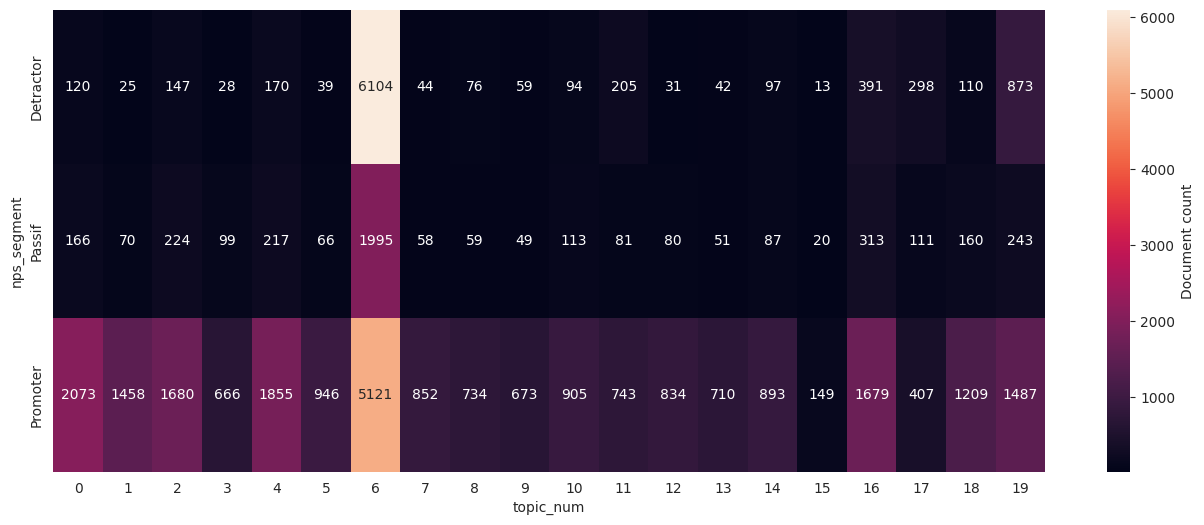

In [130]:
segment_topic = pd.crosstab(df_topics['nps_segment'], df_topics['topic_num'])
plt.figure(figsize=(16, 6))
sns.heatmap(segment_topic,
            annot=True,
            fmt='d',
            cbar_kws={'label': 'Document count'})

La distribution est cohérente, on a plus de promoteur, et le topic_0 est tout simplement "merci parfait grand reactivite bien top free julien" montrant la satisfaction cliente comme je l'avais dit dans le premier EDA un Detractor peut très bien poser un avis possitif sans pour autant vouloir faire la promotion de free, ce qui les pousses le plus souvent a mettre une note entre 0-6 sont les problème récurrent **topic_6**: "ai est probleme ete plus demande tout qu telephone toujours", les passif aussi ce distribue dans cette fenètre malgré leur neutralité cela montre que c'est un noyeau très instable dont il convient de comprendre les réelle besoin.

*Il nous faut drop quelques colonne maintenant et produire un dataset final*

In [134]:
df_topics.columns

Index(['unique_id', 'csat', 'nps', 'commentaire', 'nps_segment',
       'clean_commentaire', 'tokens', 'topic_num', 'topics'],
      dtype='object')

In [135]:
df_topics.drop(columns=['unique_id', 'topic_num', 'tokens'])

,csat,nps,commentaire,nps_segment,clean_commentaire,topics
0,3,6,on donne toutes les infos à l’engagement et im...,Detractor,donne toutes infos a l'engagement immediatemen...,ai est probleme ete plus demande tout qu telep...
1,4,7,"Saisi du Rio pas claire. Minuscule, pas Minusc...",Passif,saisi rio claire minuscule minuscule espace es...,ai est probleme ete plus demande tout qu telep...
2,5,8,Il manque la possibilité de choisir une date d...,Passif,manque possibilite choisir date portabilite en...,ai est probleme ete plus demande tout qu telep...
3,5,9,MERCI,Promoter,merci,merci parfait grand reactivite bien top free j...
4,4,8,Il manque peut-être des précisions sur la pris...,Passif,manque peut etre precisions prise charge resil...,ai est probleme ete plus demande tout qu telep...
...,...,...,...,...,...,...
38297,1,0,Je n'ai parlé avec personne,Detractor,n'ai parle personne,agreable tres personne competente ecoute telep...
38298,5,7,Merci Lucile très professionnel.,Passif,merci lucile tres professionnel,professionnel tres merci conseiller technicien...
38299,1,0,Je n'ai été contacté par personne ! En dehors ...,Detractor,n'ai ete contacte personne dehors domicile n'a...,ai est probleme ete plus demande tout qu telep...
38300,3,7,"Assez mitigée j'avoue, le questionnaire parle ...",Passif,assez mitigee j'avoue questionnaire parle sati...,ai est probleme ete plus demande tout qu telep...


In [136]:
df_topics.to_csv('data/csat_final_enriched.csv', index=False, encoding ='utf8')

Ceux-ci conclue notre topic modeling dans le prochain Notebook nous passerons au coeur du sujet c'est a dire l'utilisation d'un modèle NLP pour la classification des sentiments clients, notre modèle ne se contentera pas juste de classer en cluster notre population mais aussi d'expliquer pourquoi